<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/MEG003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

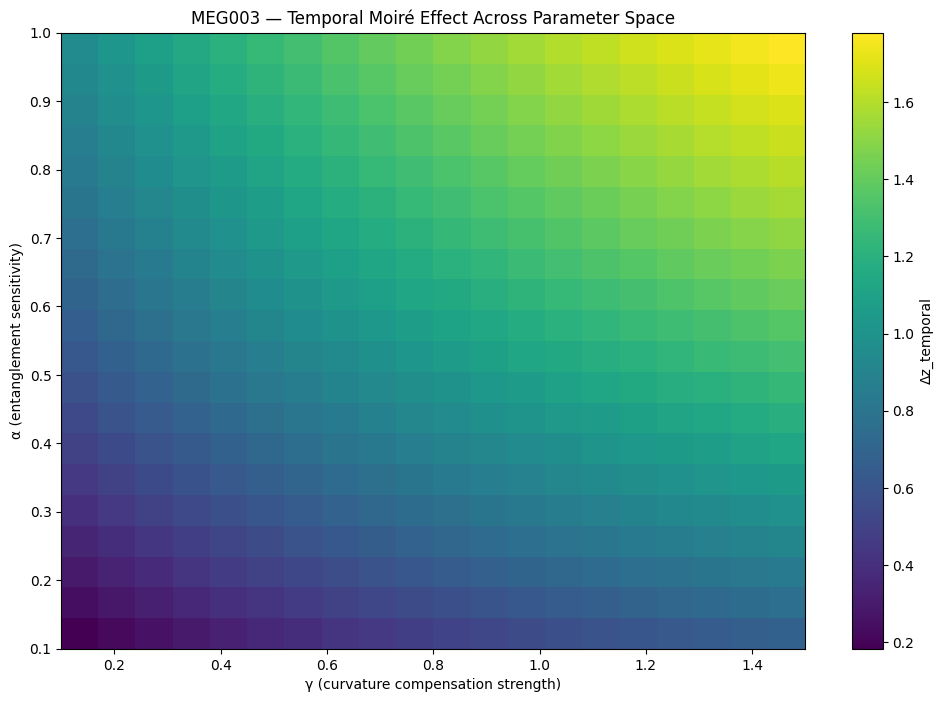

=== MEG003 SUMMARY ===
Min Δz_temporal: 0.183752
Max Δz_temporal: 1.779714
Heatmap plotted.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# MEG003 — PARAMETER SWEEP FOR TEMPORAL MOIRÉ EFFECT
# ============================================================

# 1. Synthetic void → wall matter density profile (1D)
N = 1000
x = np.linspace(0, 1, N)
rho_m = 0.2 + 0.8 * x**2   # same as MEG002

# 2. Sweep ranges for α and γ
alpha_vals = np.linspace(0.1, 1.0, 20)   # entanglement sensitivity
gamma_vals = np.linspace(0.1, 1.5, 20)   # curvature compensation

# 3. Storage for Δz_temporal results
Z = np.zeros((len(alpha_vals), len(gamma_vals)))

# 4. Fixed parameters
rho0 = 0.5
beta = 1.5

# 5. Sweep
for i, alpha in enumerate(alpha_vals):
    for j, gamma in enumerate(gamma_vals):

        # Entanglement density (saturating)
        rho_ent = rho0 + alpha * np.log1p(beta * rho_m)

        # Curvature compensation (sublinear)
        C = 1.0 + gamma * np.sqrt(rho_m)

        # Update rate
        f = 1.0 / (rho_ent * C)

        # Extract void/wall rates
        f_void = f[0]
        f_wall = f[-1]

        # Temporal Moiré term
        delta_z = (f_void - f_wall) / f_wall

        Z[i, j] = delta_z

# ============================================================
# PLOT HEATMAP
# ============================================================

plt.figure(figsize=(12, 8))
plt.imshow(Z, origin='lower', aspect='auto',
           extent=[gamma_vals[0], gamma_vals[-1], alpha_vals[0], alpha_vals[-1]],
           cmap='viridis')

plt.colorbar(label="Δz_temporal")
plt.xlabel("γ (curvature compensation strength)")
plt.ylabel("α (entanglement sensitivity)")
plt.title("MEG003 — Temporal Moiré Effect Across Parameter Space")
plt.show()

# ============================================================
# PRINT SUMMARY
# ============================================================

print("=== MEG003 SUMMARY ===")
print(f"Min Δz_temporal: {Z.min():.6f}")
print(f"Max Δz_temporal: {Z.max():.6f}")
print("Heatmap plotted.")
